# S1 margins analysis

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path

In [2]:
path = {
'coords': '/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/coordinates_seagrid_SalishSea201702.nc',
'mask': '/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/mesh_mask202108_TDV.nc',
'bathy':'/home/vicentev/projects/def-allen/vicentev/analysis-vicente/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [3]:
def finder2(target_lat, target_lon,mask=mask):
    lat = mask.nav_lat
    lon = mask.nav_lon
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [4]:
Sx1_1, Sy1_1 = [202,292], [505,505]
Sx1_2, Sy1_2 = [300,315], [505,480]
Sx1_3, Sy1_3 = [210,238], [500,465]
Sx1_4, Sy1_4 = [238,245], [465,410]
Sx1_5, Sy1_5 = [302, 280], [410, 470]
Sx1_6, Sy1_6 = [245,302], [410,410]
#
polygon_coords_S1 = [
    (Sx1_1[0], Sy1_1[0]),
    (Sx1_1[1], Sy1_1[1]),
    (Sx1_5[1], Sy1_5[1]),
    (Sx1_4[0], Sy1_4[0])
]
polygon_S1 = Polygon(polygon_coords_S1)
#
S1_lon_1, S1_lat_1 = [mask.nav_lon[Sy1_1[0],Sx1_1[0]].values, mask.nav_lon[Sy1_1[1],Sx1_1[1]].values], [mask.nav_lat[Sy1_1[0],Sx1_1[0]].values, mask.nav_lat[Sy1_1[1],Sx1_1[1]].values]
S1_lon_2, S1_lat_2 = [mask.nav_lon[Sy1_2[0],Sx1_2[0]].values, mask.nav_lon[Sy1_2[1],Sx1_2[1]].values], [mask.nav_lat[Sy1_2[0],Sx1_2[0]].values, mask.nav_lat[Sy1_2[1],Sx1_2[1]].values]
S1_lon_3, S1_lat_3 = [mask.nav_lon[Sy1_3[0],Sx1_3[0]].values, mask.nav_lon[Sy1_3[1],Sx1_3[1]].values], [mask.nav_lat[Sy1_3[0],Sx1_3[0]].values, mask.nav_lat[Sy1_3[1],Sx1_3[1]].values]
S1_lon_4, S1_lat_4 = [mask.nav_lon[Sy1_4[0],Sx1_4[0]].values, mask.nav_lon[Sy1_4[1],Sx1_4[1]].values], [mask.nav_lat[Sy1_4[0],Sx1_4[0]].values, mask.nav_lat[Sy1_4[1],Sx1_4[1]].values]
S1_lon_5, S1_lat_5 = [mask.nav_lon[Sy1_5[0],Sx1_5[0]].values, mask.nav_lon[Sy1_5[1],Sx1_5[1]].values], [mask.nav_lat[Sy1_5[0],Sx1_5[0]].values, mask.nav_lat[Sy1_5[1],Sx1_5[1]].values]
S1_lon_6, S1_lat_6 = [mask.nav_lon[Sy1_6[0],Sx1_6[0]].values, mask.nav_lon[Sy1_6[1],Sx1_6[1]].values], [mask.nav_lat[Sy1_6[0],Sx1_6[0]].values, mask.nav_lat[Sy1_6[1],Sx1_6[1]].values]
#
polygon_lon_lat_S1 = [
    (S1_lon_1[0], S1_lat_1[0]),
    (S1_lon_1[1], S1_lat_1[1]),
    (S1_lon_5[1], S1_lat_5[1]),
    (S1_lon_4[0], S1_lat_4[0])
]
polygon_coors_S1 = Polygon(polygon_lon_lat_S1)

In [5]:
S415 = [49.25, -123.667]
y_S1, x_S1 = finder2(S415[0], S415[1])

(<matplotlib.patches.PathPatch at 0x7f06dbe196a0>,
 <matplotlib.lines.Line2D at 0x7f06dbe25590>)

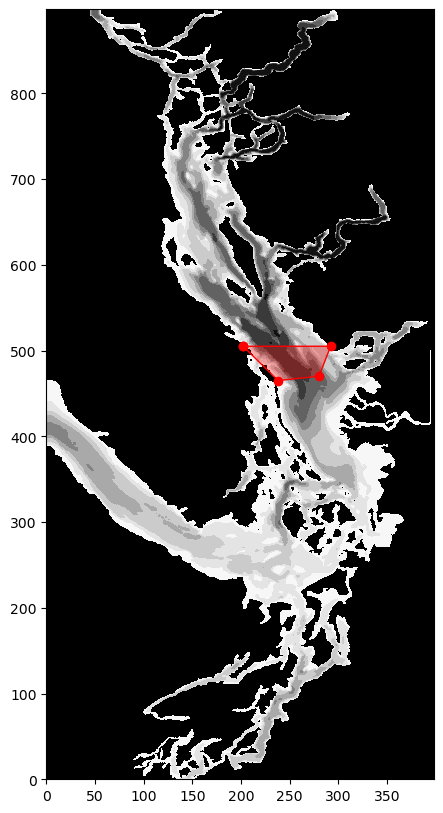

In [6]:
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
fig, ax = plt.subplots(figsize = (5,10))
ax.pcolormesh(mask['tmask'][0][0], cmap = cmap)
ax.contourf(bathy['Bathymetry'], cmap = 'Greys')
plot_polygon(polygon_S1, ax=ax, color = 'r', label = 'Region S1')


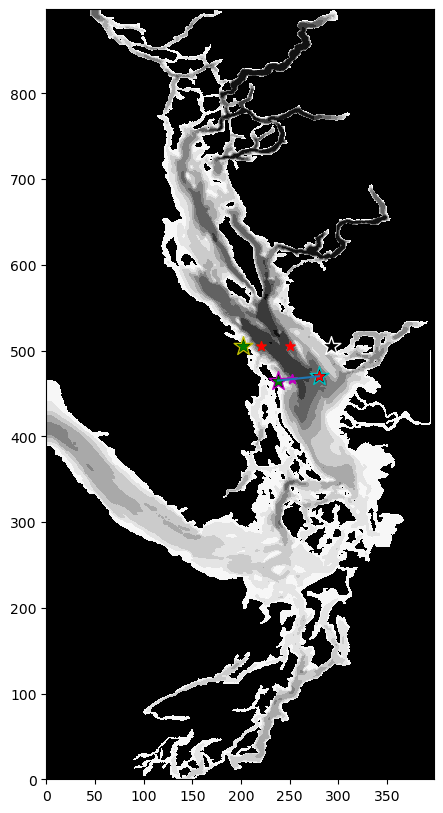

In [7]:
Sx1_1, Sy1_1 = [202,292], [505,505]
Sx1_2, Sy1_2 = [300,315], [505,480]
Sx1_3, Sy1_3 = [210,238], [500,465]
Sx1_4, Sy1_4 = [238,245], [465,410]
Sx1_5, Sy1_5 = [302, 280], [410, 470]
Sx1_6, Sy1_6 = [245,302], [410,410]
#
SxL_1, SyL_1 = [202,292], [505,505]
SxL_2, SyL_2 = [238,245], [465,410]
SxL_3, SyL_3 = [220,292], [505,505]
SxL_4, SyL_4 = [252,245], [467,410]
#
SxC_1, SyC_1 = [220,292], [505,505]
SxC_2, SyC_2 = [252,245], [467,410]
SxC_3, SyC_3 = [250,292], [505,505]
SxC_4, SyC_4 = [302, 280], [410, 470]
#
SxR_3, SyR_3 = [250,292], [505,505]
SxR_1, SyR_1 = [202,292], [505,505]
SxR_4, SyR_4 = [302, 280], [410, 470]
#
fig, ax = plt.subplots(figsize = (5,10))
ax.pcolormesh(mask['tmask'][0][0], cmap = cmap)
ax.contourf(bathy['Bathymetry'], cmap = 'Greys')
#
ax.scatter(Sx1_1[0], Sy1_1[0], s=200, color='k', marker='*', edgecolors='y')
ax.scatter(Sx1_1[1], Sy1_1[1], s=200, color='k', marker='*', edgecolors='w')
ax.scatter(Sx1_5[1], Sy1_5[1], s=200, color='k', marker='*', edgecolors='c')
ax.scatter(Sx1_4[0], Sy1_4[0], s=200, color='k', marker='*', edgecolors='m')

#
ax.scatter(SxL_1[0], SyL_1[0], s=50, color='g', marker='*')
ax.scatter(SxL_2[0], SyL_2[0], s=50, color='g', marker='*')
ax.scatter(SxL_3[0], SyL_3[0], s=50, color='g', marker='*')
ax.scatter(SxL_4[0], SyL_4[0], s=50, color='m', marker='*')
#
ax.scatter(SxC_1[0], SyC_1[0], s=50, color='r', marker='*')
ax.scatter(SxC_2[0], SyC_2[0], s=50, color='m', marker='*')
ax.scatter(SxC_3[0], SyC_3[0], s=50, color='r', marker='*')
ax.scatter(SxC_4[1], SyC_4[1], s=50, color='r', marker='*')
#
ax.plot([Sx1_4[0], Sx1_5[1]], [Sy1_4[0], Sy1_5[1]])


In [8]:
polygon_coords_S1_L = [
    (SxL_1[0], SyL_1[0]),
    (SxL_3[0], SyL_3[0]),
    (SxL_4[0], SyL_4[0]),
    (SxL_2[0], SyL_2[0])
]
polygon_S1_L = Polygon(polygon_coords_S1_L)
#
polygon_coords_S1_C = [
    (SxC_1[0], SyC_1[0]),
    (SxC_3[0], SyC_3[0]),
    (SxC_4[1], SyC_4[1]),
    (SxC_2[0], SyC_2[0])
]
polygon_S1_C = Polygon(polygon_coords_S1_C)
#
polygon_coords_S1_R = [
    (SxR_3[0], SyR_3[0]),
    (SxR_1[1], SyR_1[1]),
    (SxR_4[1], SyR_4[1])
]
polygon_S1_R = Polygon(polygon_coords_S1_R)


In [9]:
S1L_lon_1, S1L_lat_1 = [mask.nav_lon[SyL_1[0],SxL_1[0]].values, mask.nav_lon[SyL_1[1],SxL_1[1]].values], [mask.nav_lat[SyL_1[0],SxL_1[0]].values, mask.nav_lat[SyL_1[1],SxL_1[1]].values]
S1L_lon_2, S1L_lat_2 = [mask.nav_lon[SyL_2[0],SxL_2[0]].values, mask.nav_lon[SyL_2[1],SxL_2[1]].values], [mask.nav_lat[SyL_2[0],SxL_2[0]].values, mask.nav_lat[SyL_2[1],SxL_2[1]].values]
S1L_lon_3, S1L_lat_3 = [mask.nav_lon[SyL_3[0],SxL_3[0]].values, mask.nav_lon[SyL_3[1],SxL_3[1]].values], [mask.nav_lat[SyL_3[0],SxL_3[0]].values, mask.nav_lat[SyL_3[1],SxL_3[1]].values]
S1L_lon_4, S1L_lat_4 = [mask.nav_lon[SyL_4[0],SxL_4[0]].values, mask.nav_lon[SyL_4[1],SxL_4[1]].values], [mask.nav_lat[SyL_4[0],SxL_4[0]].values, mask.nav_lat[SyL_4[1],SxL_4[1]].values]
#
polygon_lon_lat_S1_L = [
    (S1L_lon_1[0], S1L_lat_1[0]),
    (S1L_lon_3[0], S1L_lat_3[0]),
    (S1L_lon_4[0], S1L_lat_4[0]),
    (S1L_lon_2[0], S1L_lat_2[0])
]
polygon_coors_S1_L = Polygon(polygon_lon_lat_S1_L)
######
S1C_lon_1, S1C_lat_1 = [mask.nav_lon[SyC_1[0],SxC_1[0]].values, mask.nav_lon[SyC_1[1],SxC_1[1]].values], [mask.nav_lat[SyC_1[0],SxC_1[0]].values, mask.nav_lat[SyC_1[1],SxC_1[1]].values]
S1C_lon_2, S1C_lat_2 = [mask.nav_lon[SyC_2[0],SxC_2[0]].values, mask.nav_lon[SyC_2[1],SxC_2[1]].values], [mask.nav_lat[SyC_2[0],SxC_2[0]].values, mask.nav_lat[SyC_2[1],SxC_2[1]].values]
S1C_lon_3, S1C_lat_3 = [mask.nav_lon[SyC_3[0],SxC_3[0]].values, mask.nav_lon[SyC_3[1],SxC_3[1]].values], [mask.nav_lat[SyC_3[0],SxC_3[0]].values, mask.nav_lat[SyC_3[1],SxC_3[1]].values]
S1C_lon_4, S1C_lat_4 = [mask.nav_lon[SyC_4[0],SxC_4[0]].values, mask.nav_lon[SyC_4[1],SxC_4[1]].values], [mask.nav_lat[SyC_4[0],SxC_4[0]].values, mask.nav_lat[SyC_4[1],SxC_4[1]].values]
#
polygon_lon_lat_S1_C = [
    (S1C_lon_1[0], S1C_lat_1[0]),
    (S1C_lon_3[0], S1C_lat_3[0]),
    (S1C_lon_4[1], S1C_lat_4[1]),
    (S1C_lon_2[0], S1C_lat_2[0])
]
polygon_coors_S1_C = Polygon(polygon_lon_lat_S1_C)
######

S1R_lon_1, S1R_lat_1 = [mask.nav_lon[SyR_1[0],SxR_1[0]].values, mask.nav_lon[SyR_1[1],SxR_1[1]].values], [mask.nav_lat[SyR_1[0],SxR_1[0]].values, mask.nav_lat[SyR_1[1],SxR_1[1]].values]
S1R_lon_3, S1R_lat_3 = [mask.nav_lon[SyR_3[0],SxR_3[0]].values, mask.nav_lon[SyR_3[1],SxR_3[1]].values], [mask.nav_lat[SyR_3[0],SxR_3[0]].values, mask.nav_lat[SyR_3[1],SxR_3[1]].values]
S1R_lon_4, S1R_lat_4 = [mask.nav_lon[SyR_4[0],SxR_4[0]].values, mask.nav_lon[SyR_4[1],SxR_4[1]].values], [mask.nav_lat[SyR_4[0],SxR_4[0]].values, mask.nav_lat[SyR_4[1],SxR_4[1]].values]
#
polygon_lon_lat_S1_R = [
    (S1R_lon_3[0], S1R_lat_3[0]),
    (S1R_lon_1[1], S1R_lat_1[1]),
    (S1R_lon_4[1], S1R_lat_4[1])
]
polygon_coors_S1_R = Polygon(polygon_lon_lat_S1_R)


/tmp/ipykernel_1400307/2688457147.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax[1].pcolormesh(mask['nav_lon'], mask['nav_lat'], mask['tmask'][0][0], cmap = cmap)


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


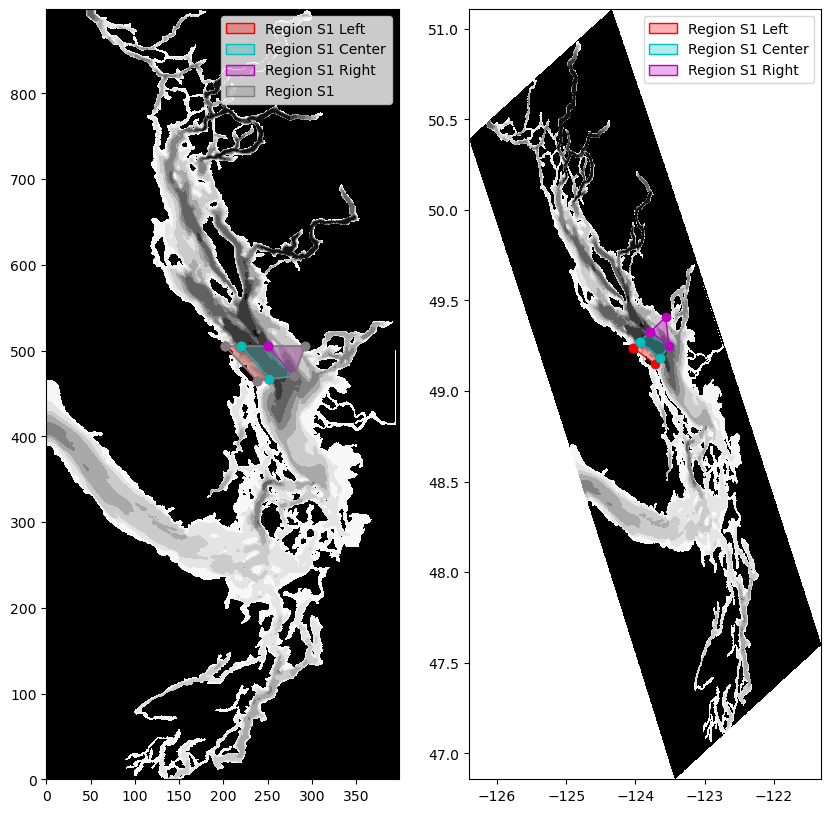

In [10]:
fig, ax = plt.subplots(1,2,figsize = (10,10))
ax[0].pcolormesh(mask['tmask'][0][0], cmap = cmap)
ax[0].contourf(bathy['Bathymetry'], cmap = 'Greys')
plot_polygon(polygon_S1_L, ax=ax[0], color = 'r', label = 'Region S1 Left')
plot_polygon(polygon_S1_C, ax=ax[0], color = 'c', label = 'Region S1 Center')
plot_polygon(polygon_S1_R, ax=ax[0], color = 'm', label = 'Region S1 Right')
plot_polygon(polygon_S1, ax=ax[0], color = 'tab:grey', label = 'Region S1')

ax[0].legend()
#
ax[1].pcolormesh(mask['nav_lon'], mask['nav_lat'], mask['tmask'][0][0], cmap = cmap)
ax[1].contourf(bathy['nav_lon'], bathy['nav_lat'], bathy['Bathymetry'], cmap = 'Greys')
plot_polygon(polygon_coors_S1_L, ax=ax[1], color = 'r', label = 'Region S1 Left')
plot_polygon(polygon_coors_S1_C, ax=ax[1], color = 'c', label = 'Region S1 Center')
plot_polygon(polygon_coors_S1_R, ax=ax[1], color = 'm', label = 'Region S1 Right')
ax[1].legend()

In [11]:
def volume_region_50m_bottom(polygon):
    mesh = xr.open_dataset(path['mask'])
    volume = mesh['volume']
    mask = xr.open_dataset(path['mask'])['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = depths >= 50
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Polygon Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # to 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    # inside polygon  + in water + > 50 m
    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    # Applying mask
    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [12]:
volume_S1_LEFT = volume_region_50m_bottom(polygon_S1_L)
volume_S1_CENTER = volume_region_50m_bottom(polygon_S1_C)
volume_S1_RIGHT = volume_region_50m_bottom(polygon_S1_R)
#
print(volume_S1_LEFT/1e9, 'km^3')
print(volume_S1_CENTER/1e9, 'km^3')
print(volume_S1_RIGHT/1e9, 'km^3')

11.813293026 km^3
73.461531941 km^3
23.228346822 km^3


In [13]:
def polygon_definition_data_colloidal(ds, region_polygon,  depth_min=50):
#
    lons = ds['lon'].values
    lats = ds['lat'].values
    depths = ds['z'].values
    statuses = ds['status'].values
    #
    points_flat = np.column_stack((lons.ravel(), lats.ravel()))
    poly_path = Path(region_polygon)
    # points inside polygon
    inside_mask_flat = poly_path.contains_points(points_flat)
    inside_mask = inside_mask_flat.reshape(lons.shape)
    # >= 50 mask
    deep_mask = depths >= depth_min
    #deep_mask = depths >= depth_min
    # Colloidal status 
    status_mask = np.isin(statuses, 2) 
    #
    valid_mask = inside_mask & deep_mask & status_mask
    #
    counts = np.sum(valid_mask, axis=0) 
    #
    times = ds['time'].values
    time_index = np.nanmax(times, axis=0) 
    #
    return pd.DataFrame({'count': counts}, index=time_index)

In [14]:
path_sim = '/home/vicentev/scratch/vicentev/long_term_simulation.nc'
simulation_2007 = xr.open_dataset(path_sim).isel(obs = slice(None, 4380))

In [15]:
october_2007 = simulation_2007.isel(obs=slice(3276, 3648))

In [ ]:
counts_oct_2007_S1_L = polygon_definition_data_colloidal(october_2007, polygon_lon_lat_S1_L)
counts_oct_2007_S1_C = polygon_definition_data_colloidal(october_2007, polygon_lon_lat_S1_C)
counts_oct_2007_S1_R = polygon_definition_data_colloidal(october_2007, polygon_lon_lat_S1_R)

In [ ]:
concentration_oct_2007_S1_L = counts_oct_2007_S1_L.sum() / volume_S1_LEFT / len(counts_oct_2007_S1_L)
concentration_oct_2007_S1_C = counts_oct_2007_S1_C.sum() / volume_S1_CENTER / len(counts_oct_2007_S1_C)
concentration_oct_2007_S1_R = counts_oct_2007_S1_R.sum() / volume_S1_RIGHT / len(counts_oct_2007_S1_R)

In [ ]:
print('The Concentrations at S1 LEFT is: ', concentration_oct_2007_S1_L.values)
print('The Concentrations at S1 CENTER is: ', concentration_oct_2007_S1_C.values)
print('The Concentrations at S1 RIGHT is: ', concentration_oct_2007_S1_R.values)

The Concentrations at S1 LEFT is:  [1.1043009e-08]
The Concentrations at S1 CENTER is:  [1.9083867e-08]
The Concentrations at S1 RIGHT is:  [1.76267757e-08]


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


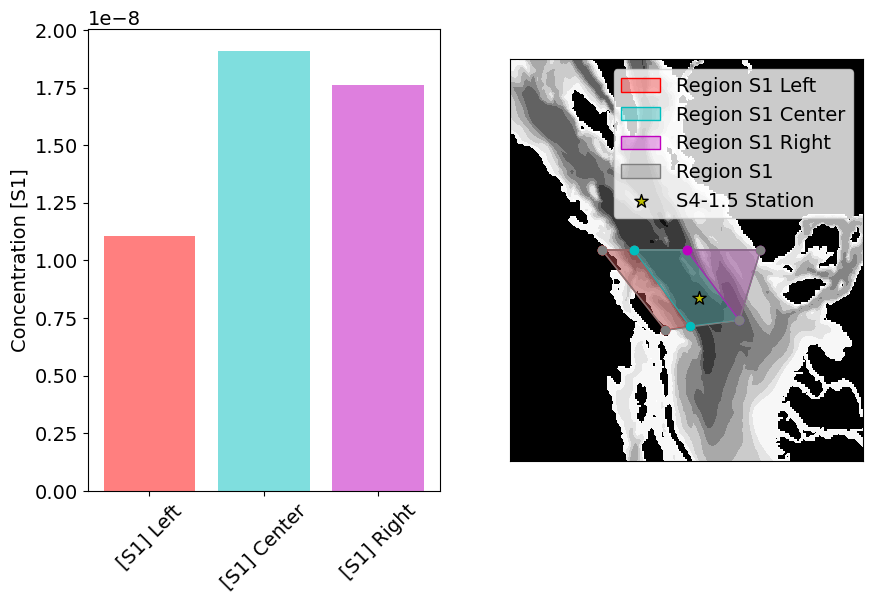

In [ ]:
plt.rcParams.update({'font.size': 14})
#
fig, ax = plt.subplots(1, 2, figsize = (10,6))
ax[0].bar(
    ['[S1] Left', '[S1] Center', '[S1] Right'],
    [concentration_oct_2007_S1_L.item(),
     concentration_oct_2007_S1_C.item(),
     concentration_oct_2007_S1_R.item()], color = ['r', 'c', 'm'], alpha = .5
)
ax[0].set_ylabel('Concentration [S1]')
ax[0].tick_params(axis='x', labelrotation=45)
#
ax[1].pcolormesh(mask['tmask'][0][0], cmap = cmap)
ax[1].contourf(bathy['Bathymetry'], cmap = 'Greys')
plot_polygon(polygon_S1_L, ax=ax[1], color = 'r', label = 'Region S1 Left')
plot_polygon(polygon_S1_C, ax=ax[1], color = 'c', label = 'Region S1 Center')
plot_polygon(polygon_S1_R, ax=ax[1], color = 'm', label = 'Region S1 Right')
plot_polygon(polygon_S1, ax=ax[1], color = 'tab:grey', label = 'Region S1')

ax[1].scatter(x_S1, y_S1, c = 'y', marker = '*', s = 100, edgecolor = 'k', label = 'S4-1.5 Station')
ax[1].legend()
ax[1].set_aspect(1.14)
ax[1].set_ylim(400, 600); ax[1].set_xlim(150, 350)
ax[1].tick_params(which='both',bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

In [72]:
tests_files = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_005_Ads_0_05_Vel_Hx1_2.nc',
 '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_0025_Ads_0_01_Vel_N.nc',
 '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_0025_Ads_0_01_Vel_Hx1_2.nc',
 '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_0025_Ads_0_1_Vel_N.nc',
 '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_0025_Ads_0_1_Vel_Hx1_2.nc',
 '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112007_run_365_days_MC_0_2_Tau_0_001_Ads_0_05_Vel_N.zarr']

In [73]:
data1 = xr.open_dataset(tests_files[0])
data2 = xr.open_dataset(tests_files[1])
data3 = xr.open_dataset(tests_files[2])
data4 = xr.open_dataset(tests_files[3])
data5 = xr.open_dataset(tests_files[4])
data6 = xr.open_dataset(tests_files[5])


In [74]:
counts_t1_S1_L = polygon_definition_data_colloidal(data1.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_L)
counts_t1_S1_C = polygon_definition_data_colloidal(data1.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_C)
counts_t1_S1_R = polygon_definition_data_colloidal(data1.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_R)

In [75]:
concentration_t1_S1_L = counts_t1_S1_L.sum() / volume_S1_LEFT / len(counts_t1_S1_L)
concentration_t1_S1_C = counts_t1_S1_C.sum() / volume_S1_CENTER / len(counts_t1_S1_C)
concentration_t1_S1_R = counts_t1_S1_R.sum() / volume_S1_RIGHT / len(counts_t1_S1_R)

In [76]:
counts_t2_S1_L = polygon_definition_data_colloidal(data2.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_L)
counts_t2_S1_C = polygon_definition_data_colloidal(data2.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_C)
counts_t2_S1_R = polygon_definition_data_colloidal(data2.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_R)

In [77]:
concentration_t2_S1_L = counts_t2_S1_L.sum() / volume_S1_LEFT / len(counts_t2_S1_L)
concentration_t2_S1_C = counts_t2_S1_C.sum() / volume_S1_CENTER / len(counts_t2_S1_C)
concentration_t2_S1_R = counts_t2_S1_R.sum() / volume_S1_RIGHT / len(counts_t2_S1_R)

In [78]:
counts_t3_S1_L = polygon_definition_data_colloidal(data3.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_L)
counts_t3_S1_C = polygon_definition_data_colloidal(data3.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_C)
counts_t3_S1_R = polygon_definition_data_colloidal(data3.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_R)

In [79]:
concentration_t3_S1_L = counts_t3_S1_L.sum() / volume_S1_LEFT / len(counts_t3_S1_L)
concentration_t3_S1_C = counts_t3_S1_C.sum() / volume_S1_CENTER / len(counts_t3_S1_C)
concentration_t3_S1_R = counts_t3_S1_R.sum() / volume_S1_RIGHT / len(counts_t3_S1_R)

In [80]:
counts_t4_S1_L = polygon_definition_data_colloidal(data4.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_L)
counts_t4_S1_C = polygon_definition_data_colloidal(data4.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_C)
counts_t4_S1_R = polygon_definition_data_colloidal(data4.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_R)

In [81]:
concentration_t4_S1_L = counts_t4_S1_L.sum() / volume_S1_LEFT / len(counts_t4_S1_L)
concentration_t4_S1_C = counts_t4_S1_C.sum() / volume_S1_CENTER / len(counts_t4_S1_C)
concentration_t4_S1_R = counts_t4_S1_R.sum() / volume_S1_RIGHT / len(counts_t4_S1_R)

In [82]:
counts_t5_S1_L = polygon_definition_data_colloidal(data5.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_L)
counts_t5_S1_C = polygon_definition_data_colloidal(data5.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_C)
counts_t5_S1_R = polygon_definition_data_colloidal(data5.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_R)

In [83]:
concentration_t5_S1_L = counts_t5_S1_L.sum() / volume_S1_LEFT / len(counts_t5_S1_L)
concentration_t5_S1_C = counts_t5_S1_C.sum() / volume_S1_CENTER / len(counts_t5_S1_C)
concentration_t5_S1_R = counts_t5_S1_R.sum() / volume_S1_RIGHT / len(counts_t5_S1_R)

In [84]:
counts_t6_S1_L = polygon_definition_data_colloidal(data6.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_L)
counts_t6_S1_C = polygon_definition_data_colloidal(data6.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_C)
counts_t6_S1_R = polygon_definition_data_colloidal(data6.isel(obs=slice(1092,1215)), polygon_lon_lat_S1_R)

In [85]:
concentration_t6_S1_L = counts_t6_S1_L.sum() / volume_S1_LEFT / len(counts_t6_S1_L)
concentration_t6_S1_C = counts_t6_S1_C.sum() / volume_S1_CENTER / len(counts_t6_S1_C)
concentration_t6_S1_R = counts_t6_S1_R.sum() / volume_S1_RIGHT / len(counts_t6_S1_R)

In [86]:
left_tests = [concentration_t1_S1_L.values, concentration_t2_S1_L.values, concentration_t3_S1_L.values, concentration_t4_S1_L.values, concentration_t5_S1_L.values, concentration_t6_S1_L.values]
center_tests = [concentration_t1_S1_C.values, concentration_t2_S1_C.values, concentration_t3_S1_C.values, concentration_t4_S1_C.values, concentration_t5_S1_C.values, concentration_t6_S1_C.values]
right_tests = [concentration_t1_S1_R.values, concentration_t2_S1_R.values, concentration_t3_S1_R.values, concentration_t4_S1_R.values, concentration_t5_S1_R.values, concentration_t6_S1_R.values]

In [87]:
lista = np.ones(5)

In [88]:
right_tests

[array([5.82201452e-08]),
 array([1.82721094e-08]),
 array([2.18985307e-08]),
 array([1.68608816e-08]),
 array([2.0286049e-08]),
 array([5.61673548e-08])]

([<matplotlib.axis.XTick at 0x7f06b8b79a90>,
 [Text(0, 0, 'Left'), Text(1, 0, 'Center'), Text(2, 0, 'Right')])

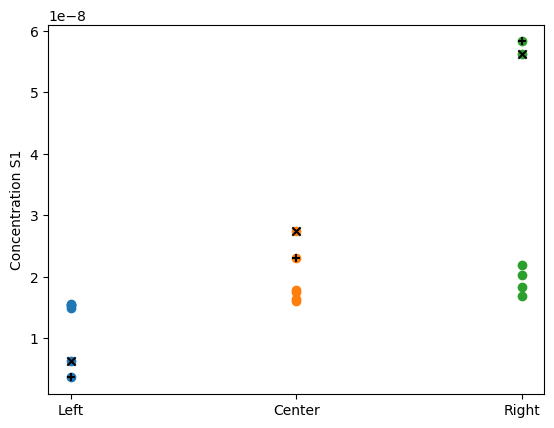

In [89]:
x_left = [0] * len(left_tests)
x_center = [1] * len(center_tests)
x_right = [2] * len(right_tests)

plt.scatter(x_left, left_tests)
plt.scatter(0, left_tests[0], marker = '+', c = 'k')
plt.scatter(0, left_tests[-1], marker = 'x', c = 'k')

plt.scatter(x_center, center_tests)
plt.scatter(1, center_tests[0], marker = '+', c = 'k')
plt.scatter(1, center_tests[-1], marker = 'x', c = 'k')

plt.scatter(x_right, right_tests)
plt.scatter(2, right_tests[0], marker = '+', c = 'k')
plt.scatter(2, right_tests[-1], marker = 'x', c = 'k')
plt.ylabel('Concentration S1')
plt.xticks([0, 1, 2], ['Left', 'Center', 'Right'])